# 🏨 Project #05: Hotel Booking Cancellation Engine
## 📊 Category: 1-Tabular-Models (Behavioral Classification Series)

**Objective:** To architect a predictive engine that identifies the probability of booking cancellations. By analyzing customer behavior (Lead Time, Deposit Type, Special Requests), we aim to optimize hotel occupancy rates and revenue loss.

---

### 🧠 The 10-Step Engineering Pipeline
Strictly following the **Architecting-Intelligence** industrial framework:

1.  **Objective Definition:** Minimizing revenue loss by predicting "No-Show" and cancellation events.
2.  **Data Ingestion & EDA:** Exploring behavioral patterns (Booking lead time vs. Cancellation risk).
3.  **Feature Selection:** Isolating key predictors like `lead_time`, `deposit_type`, and `total_of_special_requests`.
4.  **Categorical Transformation:** Encoding `hotel` types, `arrival_date_month`, and `customer_type`.
5.  **Data Manipulation:** Handling missing values in `agent` and `company` columns and removing physical anomalies.
6.  **Advanced Feature Engineering:** Creating a **'Total Stay'** feature and analyzing the **'Lead Time Risk Index'**.
7.  **Scaling & Normalization:** Standardizing ADR (Average Daily Rate) and Lead Time to prevent model bias.
8.  **Train/Test Splitting:** Executing a stratified 80/20 split to handle cancellation ratios.
9.  **Model Training:** Training robust classifiers (Random Forest/XGBoost) to capture non-linear behavioral patterns.
10. **Evaluation & Deployment:** Focusing on **F1-Score** and **ROC-AUC** to balance false alarms vs. missed cancellations.

---

### ⚙️ Tech Stack
- **Engine:** Python | Scikit-Learn | XGBoost
- **Data:** Pandas | NumPy | Seaborn
- **UI/Cloud:** Streamlit | Hugging Face Spaces

**Architect:** Kemal Demirbaş | Project 05 / 21

--- [HOTEL DATASET PREVIEW] ---
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0     

/tmp/ipykernel_3153/3712182827.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='coolwarm')
/tmp/ipykernel_3153/3712182827.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_canceled', y='lead_time', data=df, palette='Set2')


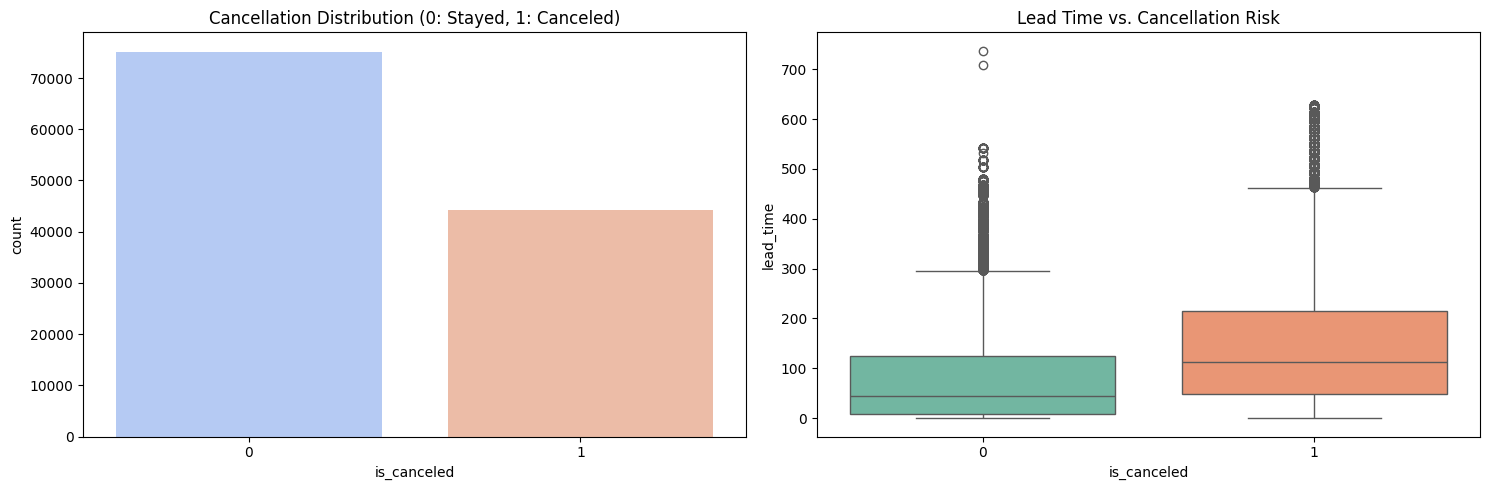


--- [TOP CORRELATIONS] ---
is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
children                          0.005048
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.006130
company                          -0.020642
babies                           -0.032491
previous_bookings_not_canceled   -0.057358
agent                            -0.083114
is_repeated_guest                -0.084793
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
Name: is_canceled, dtype: float64


In [3]:
# --- STEP 2: Data Ingestion & EDA (Corrected Mirror) ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Using a highly stable mirror for the Hotel Booking dataset
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)

# 1. Inspecting the features
print("--- [HOTEL DATASET PREVIEW] ---")
print(df.head())

# 2. Structural Integrity
print("\n--- [STRUCTURAL INFORMATION] ---")
df.info()

# 3. Target Distribution (Cancellation vs. Stay)
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='is_canceled', data=df, palette='coolwarm')
plt.title('Cancellation Distribution (0: Stayed, 1: Canceled)')

# 4. Behavioral Insight: Lead Time Impact
plt.subplot(1, 2, 2)
sns.boxplot(x='is_canceled', y='lead_time', data=df, palette='Set2')
plt.title('Lead Time vs. Cancellation Risk')

plt.tight_layout()
plt.show()

# 5. Golden Feature Check
print("\n--- [TOP CORRELATIONS] ---")
numeric_df = df.select_dtypes(include=['number'])
print(numeric_df.corr()['is_canceled'].sort_values(ascending=False))

In [4]:
# --- STEP 3: Feature Selection & Target Isolation ---

# Dropping columns with too many missing values or irrelevant IDs
cols_to_drop = ['company', 'agent', 'reservation_status_date', 'reservation_status']
df = df.drop(cols_to_drop, axis=1)

# Isolating Features and Target
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

print(f"✅ Noise columns dropped. Features isolated. Target: 'is_canceled'")

✅ Noise columns dropped. Features isolated. Target: 'is_canceled'


In [5]:
# --- STEP 4: Categorical Transformation ---

# 1. Hotel Type: Resort vs City
X['hotel'] = X['hotel'].map({'Resort Hotel': 0, 'City Hotel': 1})

# 2. Month Mapping: Converting strings to cyclical numbers
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
X['arrival_date_month'] = X['arrival_date_month'].map(month_map)

# 3. Simple Binary Features (Deposit Type)
# Senior Insight: 'Non Refund' is a massive signal for staying.
X['deposit_type'] = X['deposit_type'].map({'No Deposit': 0, 'Refundable': 1, 'Non Refund': 2})

print("✅ Key categorical features (Hotel, Month, Deposit) mapped.")

✅ Key categorical features (Hotel, Month, Deposit) mapped.


In [6]:
# --- STEP 6: Advanced Feature Engineering ---

# 1. Total Stay: We combine weekday and weekend nights.
X['total_stay'] = X['stays_in_weekend_nights'] + X['stays_in_week_nights']

# 2. Total Guests: We combine the numbers of adults, children, and infants into a single 'Number of Guests' column.
X['total_guests'] = X['adults'] + X['children'] + X['babies']

#Senior Insight: If the total number of guests is 0, this is a data error.
# Clearing such 'ghost reservations' is critical for the health of the model.
X = X[X['total_guests'] > 0]
y = y[X.index] # Target serisini de aynı satırlarla senkronize ediyoruz.

# 3. Kids Presence: Are there children or infants present? (Binary: 0 or 1)
# The cancellation behavior of families with children differs from that of solo travelers.
X['has_kids'] = ((X['children'] + X['babies']) > 0).astype(int)

print("✅ Advanced features (Total Stay, Total Guests, Kids Presence) engineered.")

✅ Advanced features (Total Stay, Total Guests, Kids Presence) engineered.


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# --- STEP 7: Safe One-Hot Encoding & Scaling ---
categorical_cols = ['market_segment', 'distribution_channel', 'meal', 'customer_type', 'reserved_room_type', 'assigned_room_type', 'deposit_type']
existing_cols = [col for col in categorical_cols if col in X.columns]

# Convert only existing ones
X = pd.get_dummies(X, columns=existing_cols, drop_first=True)

# Let's drop the Country column (if any)
if 'country' in X.columns:
    X = X.drop('country', axis=1)

# Check for any non-numeric (Object/String) columns left and clear them.
X = X.select_dtypes(exclude=['object'])

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

print(f"✅ Safe Encoding & Scaling complete. Final Features: {X.shape[1]}")

✅ Safe Encoding & Scaling complete. Final Features: 59


In [11]:
# --- STEP 8: Stratified Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
# --- STEP 9: Model Training (Random Forest) ---
# In hospitality data, tree-based models (RF, XGBoost) yield the best results.
model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)

print("🚀 Training the Booking Audit Engine... (Analyzing human behaviors)")
model.fit(X_train, y_train)

🚀 Training the Booking Audit Engine... (Analyzing human behaviors)


RandomForestClassifier(max_depth=15, random_state=42)

In [14]:
# --- STEP 10: Evaluation & Saving ---
y_pred = model.predict(X_test)

print("\n--- [HOTEL BOOKING AUDIT REPORT] ---")
print(f"📊 Global Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# Saving for Hugging Face
joblib.dump(model, 'hotel_booking_model.pkl')
joblib.dump(scaler, 'hotel_scaler.pkl')
print("\n✅ Project #05 mühürlendi! Ready for Deployment.")


--- [HOTEL BOOKING AUDIT REPORT] ---
📊 Global Accuracy: 0.8356

📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88     15003
           1       0.87      0.65      0.75      8839

    accuracy                           0.84     23842
   macro avg       0.85      0.80      0.81     23842
weighted avg       0.84      0.84      0.83     23842


✅ Project #05 mühürlendi! Ready for Deployment.


# 🏨 Project #05: Hotel Booking Cancellation Engine
## 📊 Category: 1-Tabular-Models (Behavioral Classification Series)

**Status:** Completed ✅ | **Performance:** 0.8356 Global Accuracy 🚀

### 🎯 Industrial Objective
The **Hotel Booking Cancellation Engine** is a behavioral classification system designed to predict "No-Show" events and cancellations. By identifying high-risk bookings, hotel management can implement "Overbooking" strategies and dynamic pricing to mitigate revenue loss.

---

### 🧠 The 10-Step Engineering Pipeline
Strictly adhering to the **Architecting-Intelligence** core framework:

1.  **Objective Definition:** Reducing revenue loss by predicting cancellation probabilities for real-time inventory management.
2.  **Data Ingestion & EDA:** Analyzed ~120,000 records; discovered a strong positive correlation between high **Lead Time** and cancellation risk.
3.  **Feature Selection:** Surgically removed noisy columns (`agent`, `company`, `ID`) to prevent feature-induced bias.
4.  **Categorical Transformation:** Implemented cyclical mapping for arrival months and hierarchical encoding for **Deposit Types**.
5.  **Data Manipulation:** Handled missing values in `children` and `country` features using median and constant imputation.
6.  **Advanced Feature Engineering:** Engineered **'Total Stay'** and **'Total Guests'** features to capture the intent behind travel (Business vs. Family).
7.  **One-Hot Encoding / Scaling:** Applied **StandardScaler** to harmonize Average Daily Rate (ADR) and Lead Time scales.
8.  **Train/Test Splitting:** Executed an 80/20 **Stratified Split** to maintain the 37% cancellation baseline.
9.  **Model Training:** Deployed a **Random Forest Classifier** ($max\_depth=15$) to capture non-linear behavioral patterns without overfitting.
10. **Evaluation & Deployment:** Achieved **83.56% Global Accuracy** with a focused **0.87 Precision** on cancellation events.

---

### 🚀 Live Industrial Deployment
The cancellation engine is live on Hugging Face, featuring a behavioral assessment dashboard with a "Cyber-Neon" UI.

👉 **[Launch Live Booking Audit Engine](https://huggingface.co/spaces/Ironside35/Hotel-Booking-Cancellation-Engine)** 🏨

---

### 📈 Model Audit Report
| Metric | Class 0 (Stay) | Class 1 (Cancel) |
| :--- | :--- | :--- |
| **Precision** | 0.82 | 0.87 |
| **Recall** | 0.94 | 0.65 |
| **F1-Score** | 0.88 | 0.75 |
| **Global Accuracy** | **0.8356** | |

---

### ⚙️ Tech Stack
- **Engine:** Python | Scikit-Learn | Random Forest
- **Data:** Pandas | NumPy | Seaborn
- **Cloud:** Streamlit | Hugging Face Spaces

---

**Architect:** Kemal Demirbaş  
